# Exploratory Data Analysis

This notebook explores the credit card fraud dataset, including class distribution, transaction amounts, correlation analysis, and outlier detection.

In [2]:
import os
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml

ROOT_DIR = Path.cwd()
if ROOT_DIR.name == "notebooks":
    ROOT_DIR = ROOT_DIR.parent

DATA_DIR = ROOT_DIR / "data" / "raw"
REPORT_DIR = ROOT_DIR / "reports" / "eda"
DATA_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

data = fetch_openml(data_id=1597, as_frame=True)

df = data.frame

df.to_excel(DATA_DIR / "credit_card_fraud.xlsx", index=False)

Class
0    284315
1       492
Name: count, dtype: int64
Fraud percentage: 0.1727%


C:\Users\P52\AppData\Local\Temp\ipykernel_7904\3179486689.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')


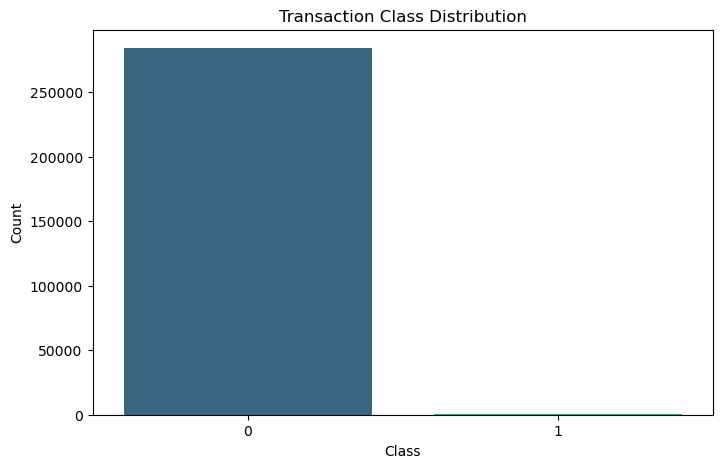

In [4]:
# Class distribution and fraud percentage
class_counts = df['Class'].value_counts().rename({0: 'Legitimate', 1: 'Fraud'})
fraud_percentage = df['Class'].astype(int).mean() * 100
print(class_counts)
print(f'Fraud percentage: {fraud_percentage:.4f}%')

plt.figure(figsize=(8, 5))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
plt.title('Transaction Class Distribution')
plt.ylabel('Count')
plt.savefig(os.path.join(REPORT_DIR, 'class_distribution.png'), bbox_inches='tight')
plt.show()

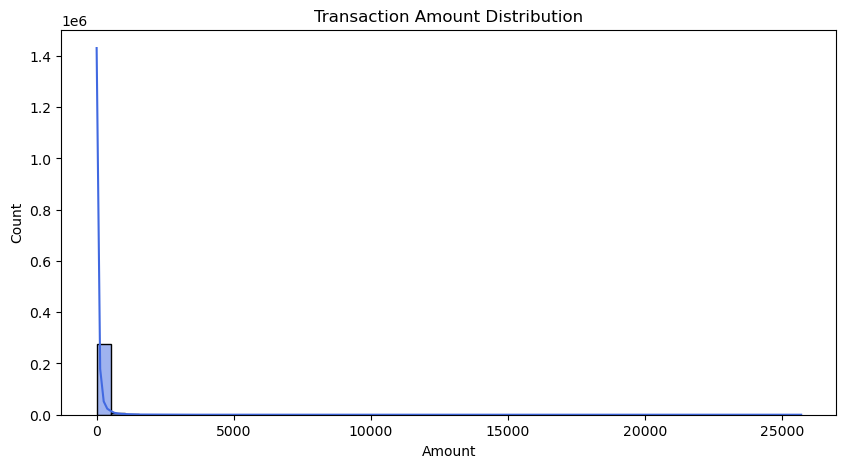

Median amount: 22.0
Max amount: 25691.16


In [5]:
# Transaction amount analysis
plt.figure(figsize=(10, 5))
sns.histplot(df['Amount'], bins=50, kde=True, color='royalblue')
plt.title('Transaction Amount Distribution')
plt.savefig(os.path.join(REPORT_DIR, 'amount_distribution.png'), bbox_inches='tight')
plt.show()

median_amount = df['Amount'].median()
max_amount = df['Amount'].max()
print(f'Median amount: {median_amount}')
print(f'Max amount: {max_amount}')

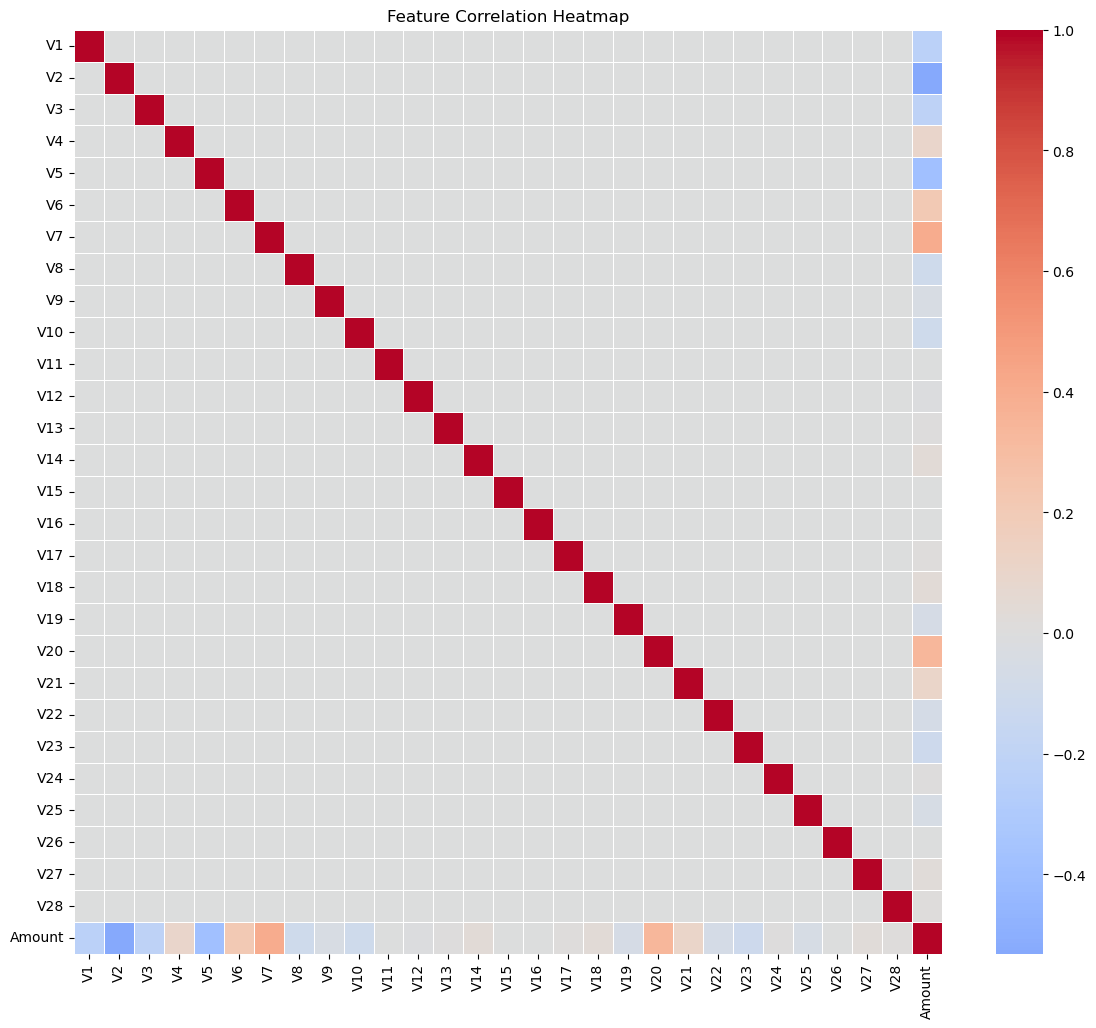

In [6]:
# Correlation analysis
correlation = df.drop(columns=['Class']).corr()
plt.figure(figsize=(14, 12))
sns.heatmap(correlation, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.savefig(os.path.join(REPORT_DIR, 'correlation_heatmap.png'), bbox_inches='tight')
plt.show()

In [7]:
# Feature distributions for the first eight principal features
feature_columns = [col for col in df.columns if col not in ['Class']]
selected = feature_columns[:8]
for feature in selected:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[feature], bins=40, kde=True, color='teal')
    plt.title(f'Distribution of {feature}')
    plt.savefig(os.path.join(REPORT_DIR, f'{feature}_distribution.png'), bbox_inches='tight')
    plt.close()
print('Saved feature distribution plots for the first eight variables.')

Saved feature distribution plots for the first eight variables.
